In [1]:
import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import re
import string

# Step 1: Data Cleaning and Preprocessing

# Load IMDB dataset (limit the vocabulary to the top 10,000 most frequent words)
num_words = 10000
(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=num_words)

# Convert integer sequences back to text (for inspection)
word_index = imdb.get_word_index()
reverse_word_index = {value: key for key, value in word_index.items()}

def decode_review(text_ints):
    """Convert list of integers back to words."""
    return ' '.join([reverse_word_index.get(i - 3, '?') for i in text_ints])

# Clean text by removing punctuation, digits, and spammy words
def clean_text(text):
    # Convert text to lowercase
    text = text.lower()

    # Remove punctuation
    text = text.translate(str.maketrans("", "", string.punctuation))
    
    # Remove digits
    text = re.sub(r'\d+', '', text)

    # Remove extra whitespaces
    text = re.sub(r'\s+', ' ', text).strip()
    
    # Remove unwanted stop words or spammy words
    spammy_words = ['free', 'click', 'buy', 'win', 'offer']
    text = ' '.join([word for word in text.split() if word not in spammy_words])

    return text

# Clean the entire training and test dataset
X_train_cleaned = [clean_text(decode_review(text)) for text in X_train]
X_test_cleaned = [clean_text(decode_review(text)) for text in X_test]

# Tokenize and pad the sequences
tokenizer = Tokenizer(num_words=num_words, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train_cleaned)

X_train_seq = tokenizer.texts_to_sequences(X_train_cleaned)
X_test_seq = tokenizer.texts_to_sequences(X_test_cleaned)

# Pad sequences to make them all have the same length (500)
X_train_pad = pad_sequences(X_train_seq, padding='post', maxlen=500)
X_test_pad = pad_sequences(X_test_seq, padding='post', maxlen=500)

# Step 2: Build RNN and LSTM Models

# Define RNN Model
def build_rnn_model(input_shape):
    model = Sequential()
    model.add(Embedding(input_dim=10000, output_dim=128, input_length=input_shape[1]))  # Embedding layer
    model.add(SimpleRNN(64, activation='tanh'))  # RNN Layer
    model.add(Dropout(0.2))  # Dropout for regularization
    model.add(Dense(1, activation='sigmoid'))  # Output layer (binary classification)
    return model

# Define LSTM Model
def build_lstm_model(input_shape):
    model = Sequential()
    model.add(Embedding(input_dim=10000, output_dim=128, input_length=input_shape[1]))  # Embedding layer
    model.add(LSTM(64))  # LSTM Layer
    model.add(Dropout(0.2))  # Dropout for regularization
    model.add(Dense(1, activation='sigmoid'))  # Output layer (binary classification)
    return model

# Step 3: Compile Models

rnn_model = build_rnn_model(X_train_pad.shape)
rnn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

lstm_model = build_lstm_model(X_train_pad.shape)
lstm_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Step 4: Early Stopping for Regularization

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# Step 5: Train Models

# Train the RNN model
rnn_history = rnn_model.fit(X_train_pad, y_train, epochs=5, batch_size=64, validation_data=(X_test_pad, y_test), callbacks=[early_stop])

# Train the LSTM model
lstm_history = lstm_model.fit(X_train_pad, y_train, epochs=5, batch_size=64, validation_data=(X_test_pad, y_test), callbacks=[early_stop])

# Step 6: Evaluate Models

# Evaluate RNN model on the test data
rnn_loss, rnn_accuracy = rnn_model.evaluate(X_test_pad, y_test)
print(f"RNN Model Accuracy: {rnn_accuracy:.4f}")

# Evaluate LSTM model on the test data
lstm_loss, lstm_accuracy = lstm_model.evaluate(X_test_pad, y_test)
print(f"LSTM Model Accuracy: {lstm_accuracy:.4f}")

# Step 7: SPAM Detection (Removing Junk Text Content)

# Detect spammy content
def detect_spam(text):
    spam_keywords = ['buy', 'win', 'offer', 'free', 'limited']
    return any(word in text for word in spam_keywords)

# Filter SPAM reviews out
filtered_X_train = [text for text in X_train_cleaned if not detect_spam(text)]
filtered_X_test = [text for text in X_test_cleaned if not detect_spam(text)]

# Tokenize and pad again after SPAM filtering
filtered_X_train_seq = tokenizer.texts_to_sequences(filtered_X_train)
filtered_X_test_seq = tokenizer.texts_to_sequences(filtered_X_test)

filtered_X_train_pad = pad_sequences(filtered_X_train_seq, padding='post', maxlen=500)
filtered_X_test_pad = pad_sequences(filtered_X_test_seq, padding='post', maxlen=500)

# You can re-train the models after SPAM filtering if needed

# Train the RNN model again on the filtered data
rnn_history_filtered = rnn_model.fit(filtered_X_train_pad, y_train[:len(filtered_X_train)], epochs=5, batch_size=64, validation_data=(filtered_X_test_pad, y_test[:len(filtered_X_test)]), callbacks=[early_stop])

# Train the LSTM model again on the filtered data
lstm_history_filtered = lstm_model.fit(filtered_X_train_pad, y_train[:len(filtered_X_train)], epochs=5, batch_size=64, validation_data=(filtered_X_test_pad, y_test[:len(filtered_X_test)]), callbacks=[early_stop])

# Evaluate the models after SPAM removal
rnn_loss_filtered, rnn_accuracy_filtered = rnn_model.evaluate(filtered_X_test_pad, y_test[:len(filtered_X_test)])
lstm_loss_filtered, lstm_accuracy_filtered = lstm_model.evaluate(filtered_X_test_pad, y_test[:len(filtered_X_test)])

print(f"RNN Model Accuracy after SPAM Filtering: {rnn_accuracy_filtered:.4f}")
print(f"LSTM Model Accuracy after SPAM Filtering: {lstm_accuracy_filtered:.4f}")


17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


C:\Users\Bim Admin\anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 89s 221ms/step - accuracy: 0.4892 - loss: 0.6982 - val_accuracy: 0.5083 - val_loss: 0.7076
Epoch 2/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 93s 238ms/step - accuracy: 0.5041 - loss: 0.7082 - val_accuracy: 0.4981 - val_loss: 0.6950
Epoch 3/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 87s 223ms/step - accuracy: 0.5046 - loss: 0.6992 - val_accuracy: 0.4997 - val_loss: 0.6932
Epoch 4/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 94s 240ms/step - accuracy: 0.5019 - loss: 0.6997 - val_accuracy: 0.5052 - val_loss: 0.6938
Epoch 5/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 92s 235ms/step - accuracy: 0.5151 - loss: 0.6940 - val_accuracy: 0.5117 - val_loss: 0.6925
Epoch 1/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 245s 616ms/step - accuracy: 0.5041 - loss: 0.6937 - val_accuracy: 0.5011 - val_loss: 0.6922
Epoch 2/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 351s 900ms/step - accuracy: 0.5074 - loss: 0.6893 - val_accuracy: 0.5093 - val_loss: 0.6899
Epoch 3/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 505s 1s/step - accuracy: 0.5260 - loss: 0.6702 - 

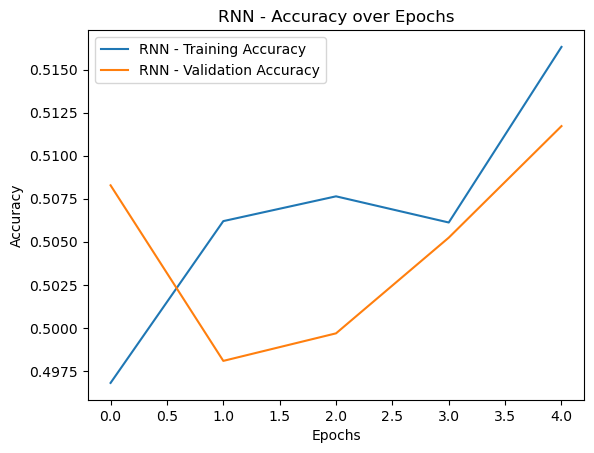

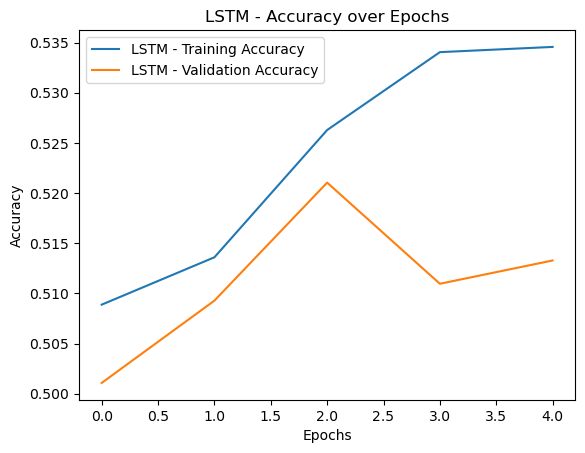

In [5]:
import matplotlib.pyplot as plt

# Plot training and validation accuracy for both RNN and LSTM models
def plot_accuracy(history, model_name):
    plt.plot(history.history['accuracy'], label=f'{model_name} - Training Accuracy')
    plt.plot(history.history['val_accuracy'], label=f'{model_name} - Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.title(f'{model_name} - Accuracy over Epochs')
    plt.legend()
    plt.show()

# Plot RNN Model Accuracy
plot_accuracy(rnn_history, "RNN")

# Plot LSTM Model Accuracy
plot_accuracy(lstm_history, "LSTM")


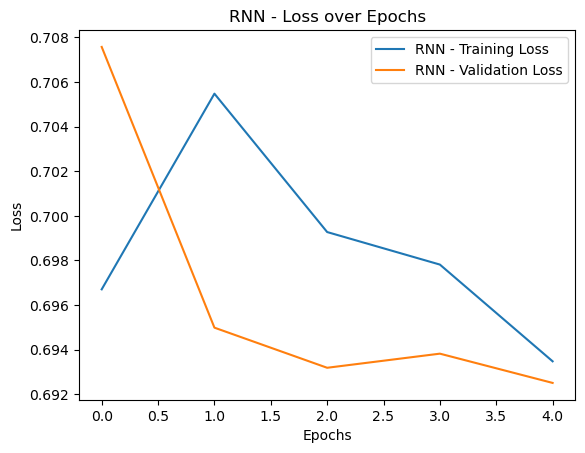

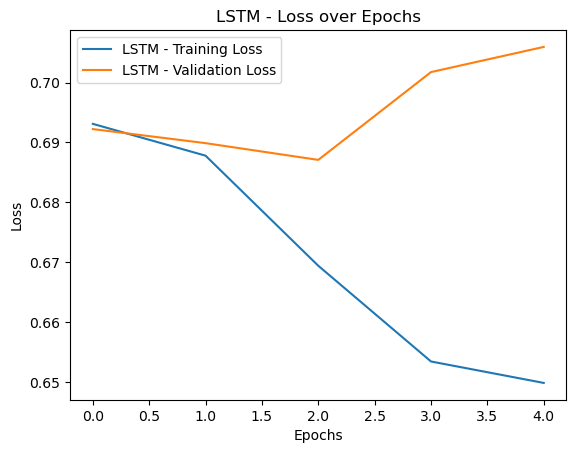

In [6]:
# Plot training and validation loss for both RNN and LSTM models
def plot_loss(history, model_name):
    plt.plot(history.history['loss'], label=f'{model_name} - Training Loss')
    plt.plot(history.history['val_loss'], label=f'{model_name} - Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title(f'{model_name} - Loss over Epochs')
    plt.legend()
    plt.show()

# Plot RNN Model Loss
plot_loss(rnn_history, "RNN")

# Plot LSTM Model Loss
plot_loss(lstm_history, "LSTM")

In [7]:

sample_reviews = ["I love this product!", "This is the worst experience ever!", "Click here to buy now!", "Great movie, highly recommend it!"]

# Clean the sample reviews before prediction
sample_reviews_cleaned = [clean_text(review) for review in sample_reviews]

# Tokenize and pad the cleaned sample reviews
sample_reviews_seq = tokenizer.texts_to_sequences(sample_reviews_cleaned)
sample_reviews_pad = pad_sequences(sample_reviews_seq, padding='post', maxlen=500)

# Predict with RNN and LSTM models
rnn_predictions = rnn_model.predict(sample_reviews_pad)
lstm_predictions = lstm_model.predict(sample_reviews_pad)

# Classify sentiment based on the predicted probability
def classify_sentiment(prediction):
    return "Positive" if prediction > 0.5 else "Negative"

rnn_sentiments = [classify_sentiment(pred[0]) for pred in rnn_predictions]
lstm_sentiments = [classify_sentiment(pred[0]) for pred in lstm_predictions]

# Visualize the Sentiment vs Probability for RNN and LSTM
import pandas as pd

# Create a DataFrame to display results
results_df = pd.DataFrame({
    'Review': sample_reviews,
    'RNN Sentiment': rnn_sentiments,
    'RNN Probability': rnn_predictions.flatten(),
    'LSTM Sentiment': lstm_sentiments,
    'LSTM Probability': lstm_predictions.flatten()
})

print(results_df)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 473ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 299ms/step
                               Review RNN Sentiment  RNN Probability  \
0                I love this product!      Negative         0.499047   
1  This is the worst experience ever!      Negative         0.499065   
2              Click here to buy now!      Negative         0.499065   
3   Great movie, highly recommend it!      Negative         0.499224   

  LSTM Sentiment  LSTM Probability  
0       Positive          0.512668  
1       Positive          0.512668  
2       Positive          0.512668  
3       Positive          0.512668  


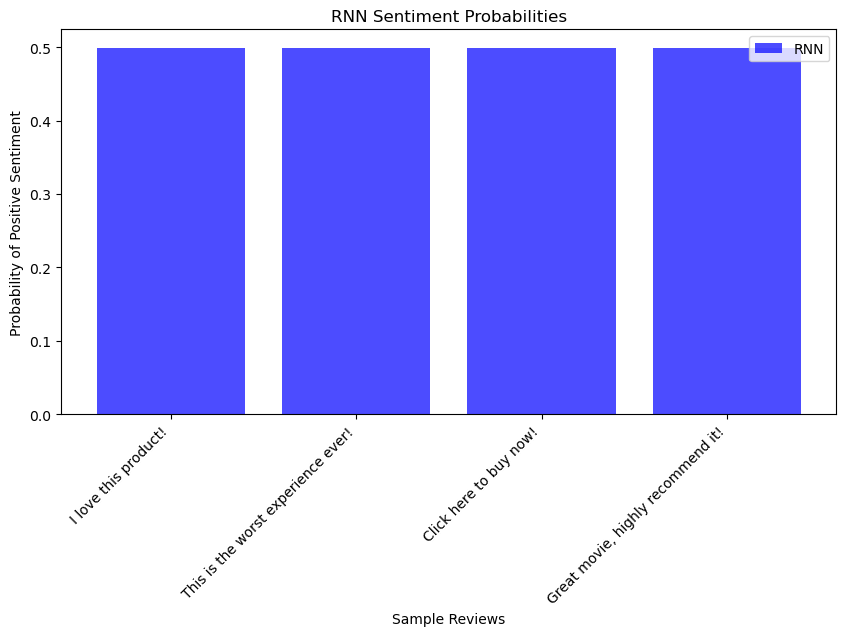

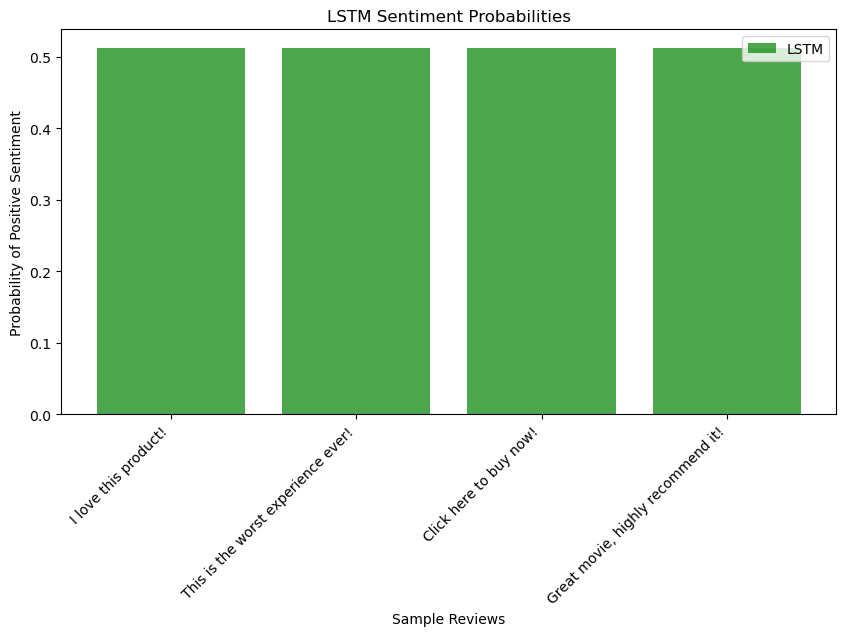

In [8]:
# Plotting Sentiment vs Probability for RNN Model
plt.figure(figsize=(10, 5))
plt.bar(results_df['Review'], results_df['RNN Probability'], color='blue', alpha=0.7, label='RNN')
plt.xlabel('Sample Reviews')
plt.ylabel('Probability of Positive Sentiment')
plt.title('RNN Sentiment Probabilities')
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.show()

# Plotting Sentiment vs Probability for LSTM Model
plt.figure(figsize=(10, 5))
plt.bar(results_df['Review'], results_df['LSTM Probability'], color='green', alpha=0.7, label='LSTM')
plt.xlabel('Sample Reviews')
plt.ylabel('Probability of Positive Sentiment')
plt.title('LSTM Sentiment Probabilities')
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.show()

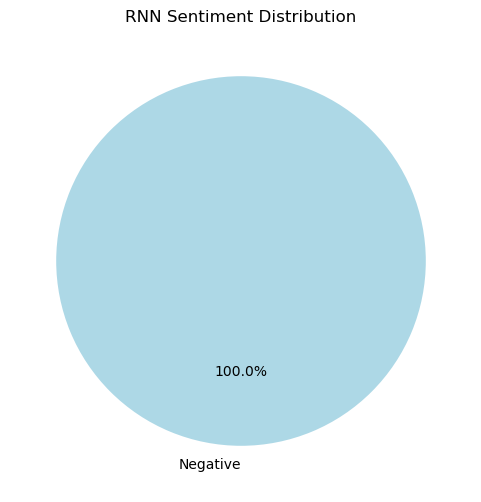

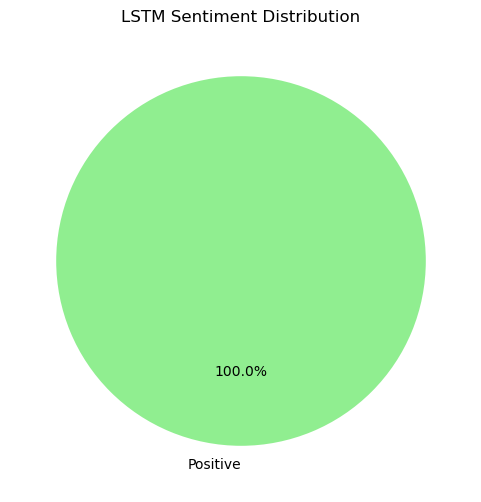

In [9]:
# Sentiment distribution in Pie Chart for RNN
rnn_sentiment_dist = results_df['RNN Sentiment'].value_counts()
plt.figure(figsize=(6, 6))
plt.pie(rnn_sentiment_dist, labels=rnn_sentiment_dist.index, autopct='%1.1f%%', startangle=90, colors=['lightblue', 'orange'])
plt.title('RNN Sentiment Distribution')
plt.show()

# Sentiment distribution in Pie Chart for LSTM
lstm_sentiment_dist = results_df['LSTM Sentiment'].value_counts()
plt.figure(figsize=(6, 6))
plt.pie(lstm_sentiment_dist, labels=lstm_sentiment_dist.index, autopct='%1.1f%%', startangle=90, colors=['lightgreen', 'lightcoral'])
plt.title('LSTM Sentiment Distribution')
plt.show()

In [10]:

# Evaluate RNN model after SPAM filtering
rnn_loss_filtered, rnn_accuracy_filtered = rnn_model.evaluate(filtered_X_test_pad, y_test[:len(filtered_X_test)])
print(f"RNN Model Accuracy after SPAM Filtering: {rnn_accuracy_filtered:.4f}")

# Evaluate LSTM model after SPAM filtering
lstm_loss_filtered, lstm_accuracy_filtered = lstm_model.evaluate(filtered_X_test_pad, y_test[:len(filtered_X_test)])
print(f"LSTM Model Accuracy after SPAM Filtering: {lstm_accuracy_filtered:.4f}")


605/605 ━━━━━━━━━━━━━━━━━━━━ 26s 43ms/step - accuracy: 0.5047 - loss: 0.6932
RNN Model Accuracy after SPAM Filtering: 0.5001
605/605 ━━━━━━━━━━━━━━━━━━━━ 62s 102ms/step - accuracy: 0.4907 - loss: 0.6943
LSTM Model Accuracy after SPAM Filtering: 0.4969
